# Casino Revenue Reinforcement Learning Optimization

## Module 2 Data Science Capstone

This project uses reinforcement learning to explore decision-making strategies for optimizing casino game revenue. The RL agent will interact with a simulated environment based on the cleaned casino revenue dataset and learn which actions produce higher rewards.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/casino_game_revenue_revised_with_store_names.csv')

In [3]:
df.shape

(2000, 16)

In [4]:
df.head()

,machine_id,location_id,store_name,month,game_type,location_type,distance_from_hq_miles,days_active,avg_bet,payout_rate,total_in,total_out,total_net,number_of_services,machine_swapouts,monthly_revenue
0,M0017,L040,Eagle Ridge Gaming,2025-06-01,Classic Reels,Gaming Hall,13.9,27,1.49,0.897,1877.52,1689.65,187.87,2,1,-400.18
1,M0140,L003,Lone Star Game Center,2026-04-01,A-Liner,Convenience Store,57.5,30,1.74,0.948,1200.00,1145.11,54.89,1,0,362.46
2,M0118,L018,Copper Creek Gaming,2025-01-01,Life of Luxury,Restaurant,18.0,21,2.24,0.915,3833.53,3388.67,444.86,1,0,-206.00
3,M0079,L021,Cedar Grove Gaming,2025-09-01,Classic Reels,Gaming Hall,50.0,26,1.20,0.858,2241.71,1876.70,365.01,0,0,87.87
4,M0078,L036,Greenfield Game Center,2026-03-01,Pot of Gold,Gaming Hall,32.5,23,2.45,0.910,7874.12,6880.70,993.42,0,0,951.83


In [5]:
df.columns

Index(['machine_id', 'location_id', 'store_name', 'month', 'game_type',
       'location_type', 'distance_from_hq_miles', 'days_active', 'avg_bet',
       'payout_rate', 'total_in', 'total_out', 'total_net',
       'number_of_services', 'machine_swapouts', 'monthly_revenue'],
      dtype='str')

In [6]:
df.describe()

,distance_from_hq_miles,days_active,avg_bet,payout_rate,total_in,total_out,total_net,number_of_services,machine_swapouts,monthly_revenue
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,56.872450,25.524000,1.648400,0.910108,2463.218345,2243.627275,219.591070,0.758000,0.138500,46.593690
std,37.902925,3.462574,0.542625,0.024609,1481.670733,1354.796362,151.865676,0.907109,0.362469,593.981576
min,2.000000,20.000000,0.250000,0.824000,1200.000000,1000.930000,20.810000,0.000000,0.000000,-900.000000
25%,28.300000,22.000000,1.290000,0.893000,1341.440000,1226.165000,120.127500,0.000000,0.000000,-398.417500
50%,48.700000,26.000000,1.640000,0.910000,2040.800000,1841.435000,173.840000,1.000000,0.000000,40.655000
75%,77.025000,29.000000,2.000000,0.927000,2994.225000,2717.267500,270.295000,1.000000,0.000000,461.227500
max,180.000000,31.000000,3.360000,0.970000,13338.130000,12075.380000,1487.660000,6.000000,2.000000,2377.520000


## Reinforcement Learning Design

The reinforcement learning environment will model casino revenue optimization as a sequence of decisions.

- **State:** Current machine and operational conditions.
- **Action:** Operational decision selected by the agent.
- **Reward:** Revenue-based feedback used to evaluate the action.
- **Goal:** Learn a policy that maximizes cumulative revenue over time.

### State

The agent observes:

- `avg_bet`
- `payout_rate`
- `days_active`
- `number_of_services`
- `machine_swapouts`
- `monthly_revenue`

These features describe the current operating condition and performance of a casino gaming machine.

### Actions

The agent can choose one of three operational actions:

- **0 — Maintain:** Keep the current machine settings.
- **1 — Increase Bet:** Slightly increase the average bet.
- **2 — Adjust Payout:** Slightly adjust the payout rate.

The agent will learn which action produces the best long-term reward under different operating conditions.

### Reward

The reward represents the financial outcome of the agent's decision.

- Higher revenue produces a positive reward.
- Lower revenue produces a smaller reward.
- The agent's objective is to maximize cumulative reward over time.

`monthly_revenue` will be used as the primary signal for evaluating performance.

In [7]:
state_features = [
    'avg_bet',
    'payout_rate',
    'days_active',
    'number_of_services',
    'machine_swapouts',
    'monthly_revenue'
]

In [8]:
df[state_features].head()

,avg_bet,payout_rate,days_active,number_of_services,machine_swapouts,monthly_revenue
0,1.49,0.897,27,2,1,-400.18
1,1.74,0.948,30,1,0,362.46
2,2.24,0.915,21,1,0,-206.00
3,1.20,0.858,26,0,0,87.87
4,2.45,0.910,23,0,0,951.83


In [9]:
actions = {
    0: 'Maintain',
    1: 'Increase Bet',
    2: 'Adjust Payout'
}

In [10]:
actions

{0: 'Maintain', 1: 'Increase Bet', 2: 'Adjust Payout'}

In [11]:
state = df[state_features].iloc[0]

In [12]:
state


avg_bet                 1.490
payout_rate             0.897
days_active            27.000
number_of_services      2.000
machine_swapouts        1.000
monthly_revenue      -400.180
Name: 0, dtype: float64

In [13]:
reward = state['monthly_revenue']

In [14]:
reward

np.float64(-400.18)

In [15]:
action = 1

In [16]:
next_state = state.copy()

In [17]:
next_state['avg_bet'] *= 1.10

In [18]:
next_state[['avg_bet']]

avg_bet    1.639
Name: 0, dtype: float64

In [19]:
state['avg_bet']

np.float64(1.49)

In [20]:
new_reward = reward * 1.05

In [21]:
new_reward

np.float64(-420.189)

In [22]:
new_reward = reward + abs(reward) * 0.05


In [23]:
new_reward

np.float64(-380.171)

In [24]:
reward_change = new_reward - reward

In [25]:
reward_change

np.float64(20.009000000000015)

## RL Environment Logic

The next step converts the manually tested state-action-reward process into reusable environment logic. This allows the agent to apply different actions to different states consistently.

In [26]:
def apply_action(state, action):
    next_state = state.copy()

    if action == 1:
        next_state['avg_bet'] *= 1.10

    elif action == 2:
        next_state['payout_rate'] *= 0.99

    return next_state

In [27]:
test_maintain = apply_action(state, 0)

In [28]:
test_maintain.equals(state)

True

In [29]:
test_increase = apply_action(state, 1)

In [30]:
test_increase['avg_bet']

np.float64(1.639)

In [31]:
test_payout = apply_action(state, 2)

In [32]:
test_payout['payout_rate']

np.float64(0.88803)

In [33]:
print("Maintain:", test_maintain['avg_bet'], test_maintain['payout_rate'])
print("Increase Bet:", test_increase['avg_bet'], test_increase['payout_rate'])
print("Adjust Payout:", test_payout['avg_bet'], test_payout['payout_rate'])

Maintain: 1.49 0.897
Increase Bet: 1.639 0.897
Adjust Payout: 1.49 0.88803


## Reward Function

The reward function measures the change in simulated revenue after an action.

A positive reward indicates an improvement in the simulated outcome, while a negative reward indicates a deterioration.

The reward is based on the difference between the new simulated revenue and the current revenue.

In [34]:
def calculate_reward(old_revenue, new_revenue):
    return new_revenue - old_revenue

In [35]:
calculate_reward(-400.18, -380.171)

20.009000000000015

In [36]:
calculate_reward(-400.18, -420.189)


-20.009000000000015

In [37]:
print(calculate_reward(-400.18,-380.171))
print(calculate_reward(-400.18,-420.189))

20.009000000000015
-20.009000000000015


In [38]:
state_features = [
    'avg_bet',
    'payout_rate',
    'days_active',
    'number_of_services',
    'machine_swapouts'
]

In [39]:
state_features


['avg_bet',
 'payout_rate',
 'days_active',
 'number_of_services',
 'machine_swapouts']

In [40]:
state_data = df[state_features].copy()

In [41]:
state_data.shape

(2000, 5)

In [42]:
state_data.head()

,avg_bet,payout_rate,days_active,number_of_services,machine_swapouts
0,1.49,0.897,27,2,1
1,1.74,0.948,30,1,0
2,2.24,0.915,21,1,0
3,1.20,0.858,26,0,0
4,2.45,0.910,23,0,0


In [43]:
import gymnasium as gym
from gymnasium import spaces

In [44]:
class CasinoRevenueEnv(gym.Env):
    def __init__(self, data, revenue_data):
        super().__init__()

        self.data = data.reset_index(drop=True)
        self.revenue_data = revenue_data.reset_index(drop=True)

        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(5,),
            dtype=np.float32
        )

        self.current_index = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_index = 0

        observation = self.data.iloc[
            self.current_index
        ].values.astype(np.float32)

        return observation, {}

    def step(self, action):
        current_state = self.data.iloc[
            self.current_index
        ].copy()

        current_revenue = self.revenue_data.iloc[
            self.current_index
        ]

        next_state = apply_action(
            current_state,
            action
        )

        if action == 0:
            simulated_revenue = current_revenue

        elif action == 1:
            simulated_revenue = (
                current_revenue
                + abs(current_revenue) * 0.05
            )

        else:
            simulated_revenue = (
                current_revenue
                + abs(current_revenue) * 0.02
            )

        reward = calculate_reward(
            current_revenue,
            simulated_revenue
        )

        observation = next_state.values.astype(
            np.float32
        )

        terminated = True
        truncated = False

        return (
            observation,
            reward,
            terminated,
            truncated,
            {}
        )

In [45]:
env = CasinoRevenueEnv(
    state_data,
    df['monthly_revenue']
)

In [46]:
env.action_space

Discrete(3)

In [47]:
env.observation_space

Box(-inf, inf, (5,), float32)

In [48]:
obs, info = env.reset()

In [49]:
env = CasinoRevenueEnv(state_data, df['monthly_revenue'])

In [50]:
obs, reward, done, truncated, info = env.step(1)

In [51]:
reward

np.float64(20.009000000000015)

In [52]:
obs

array([ 1.639,  0.897, 27.   ,  2.   ,  1.   ], dtype=float32)

In [53]:
done, truncated

(True, False)

## Gymnasium Environment

The next stage trains an agent to select actions within the casino revenue environment.

The agent will learn from rewards received after taking actions and will attempt to maximize cumulative reward over repeated decisions.

In [54]:
class CasinoRevenueEnv(gym.Env):
    def __init__(self, data, revenue_data):
        super().__init__()

        self.data = data.reset_index(drop=True)
        self.revenue_data = revenue_data.reset_index(drop=True)

        # Three available operational actions:
        # 0 = Maintain
        # 1 = Increase Bet
        # 2 = Adjust Payout
        self.action_space = spaces.Discrete(3)

        low = np.array([
            0.0,
            0.0,
            0.0,
            0.0,
            0.0
        ], dtype=np.float32)

        high = np.array([
            self.data["avg_bet"].max() * 1.2,
            1.0,
            self.data["days_active"].max() + 1,
            self.data["number_of_services"].max() + 1,
            self.data["machine_swapouts"].max() + 1
        ], dtype=np.float32)

        self.observation_space = spaces.Box(
            low=low,
            high=high,
            dtype=np.float32
        )

        self.current_index = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_index = self.np_random.integers(
            0,
            len(self.data)
        )

        observation = self.data.iloc[
            self.current_index
        ].values.astype(np.float32)

        return observation, {}

    def step(self, action):
        current_state = self.data.iloc[
            self.current_index
        ].copy()

        current_revenue = self.revenue_data.iloc[
            self.current_index
        ]

        next_state = apply_action(
            current_state,
            action
        )

        # Read the current machine conditions.
        avg_bet = current_state["avg_bet"]
        payout_rate = current_state["payout_rate"]
        days_active = current_state["days_active"]
        services = current_state["number_of_services"]
        swapouts = current_state["machine_swapouts"]

        # -------------------------------------------------
        # STATE-DEPENDENT REWARD LOGIC
        # -------------------------------------------------
        # Each action can perform differently depending on
        # the current machine state. No action is guaranteed
        # to be best for every machine.
        # -------------------------------------------------

        if action == 0:
            # MAINTAIN
            # Maintaining the current configuration is more
            # useful when the machine appears stable.

            revenue_change = 0.01

            if services <= 1 and swapouts == 0:
                revenue_change += 0.03

            if days_active >= 25:
                revenue_change += 0.01

        elif action == 1:
            # INCREASE BET
            # Increasing the bet can help when the current
            # average bet is low, but may hurt performance
            # when the average bet is already relatively high.

            if avg_bet < 1.50:
                revenue_change = 0.06

            elif avg_bet < 2.50:
                revenue_change = 0.02

            else:
                revenue_change = -0.03

            # Machines requiring frequent service receive
            # a penalty for this more aggressive strategy.
            if services >= 3:
                revenue_change -= 0.02

        else:
            # ADJUST PAYOUT
            # Adjusting payout can be useful when the current
            # payout rate is relatively low.

            if payout_rate < 0.90:
                revenue_change = 0.05

            elif payout_rate < 0.95:
                revenue_change = 0.02

            else:
                revenue_change = -0.02

            # A previous machine swapout slightly increases
            # the simulated benefit of this adjustment.
            if swapouts > 0:
                revenue_change += 0.01

        # Apply the state-dependent simulated revenue change.
        simulated_revenue = (
            current_revenue
            + abs(current_revenue) * revenue_change
        )

        # Reward measures the simulated revenue improvement
        # produced by the selected action.
        reward = calculate_reward(
            current_revenue,
            simulated_revenue
        )

        observation = next_state.values.astype(
            np.float32
        )

        # This project uses a one-step decision environment.
        # The episode ends immediately after the selected action.
        terminated = True
        truncated = False

        # Return additional information for later evaluation.
        info = {
            "action": int(action),
            "current_revenue": float(current_revenue),
            "simulated_revenue": float(simulated_revenue),
            "revenue_change": float(revenue_change)
        }

        return (
            observation,
            reward,
            terminated,
            truncated,
            info
        )

In [55]:
env = CasinoRevenueEnv(state_data, df['monthly_revenue'])

In [56]:
obs1, info1 = env.reset(seed=42)
obs2, info2 = env.reset(seed=123)

print("First starting state:", obs1)
print("Second starting state:", obs2)
print("States are different:", not np.array_equal(obs1, obs2))

First starting state: [ 0.67   0.907 31.     0.     0.   ]
Second starting state: [ 1.48  0.9  22.    1.    0.  ]
States are different: True


In [57]:
obs, info = env.reset()

obs, reward, terminated, truncated, info = env.step(1)

print("Observation shape:", obs.shape)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)

Observation shape: (5,)
Reward: 20.569200000000023
Terminated: True
Truncated: False


## RL Agent Training

The Q-learning agent uses discretized environment states, an epsilon-greedy action policy, and a Q-table to learn which action maximizes reward.

In [58]:
from sklearn.preprocessing import KBinsDiscretizer

In [59]:
discretizer = KBinsDiscretizer(
    n_bins=[5, 5, 5, 3, 2],
    encode='ordinal',
    strategy='uniform'
)

In [60]:
discretizer.fit(state_data)

,"n_bins n_bins: int or array-like of shape (n_features,), default=5The number of bins to produce. Raises ValueError if ``n_bins < 2``.","[5, 5, ...]"
,"encode encode: {'onehot', 'onehot-dense', 'ordinal'}, default='onehot'Method used to encode the transformed result.- 'onehot': Encode the transformed result with one-hot encoding and return a sparse matrix. Ignored features are always stacked to the right.- 'onehot-dense': Encode the transformed result with one-hot encoding and return a dense array. Ignored features are always stacked to the right.- 'ordinal': Return the bin identifier encoded as an integer value.",'ordinal'
,"strategy strategy: {'uniform', 'quantile', 'kmeans'}, default='quantile'Strategy used to define the widths of the bins.- 'uniform': All bins in each feature have identical widths.- 'quantile': All bins in each feature have the same number of points.- 'kmeans': Values in each bin have the same nearest center of a 1D k-means cluster.For an example of the different strategies see::ref:`sphx_glr_auto_examples_preprocessing_plot_discretization_strategies.py`.",'uniform'
,"quantile_method quantile_method: {""inverted_cdf"", ""averaged_inverted_cdf"",""closest_observation"", ""interpolated_inverted_cdf"", ""hazen"",""weibull"", ""linear"", ""median_unbiased"", ""normal_unbiased""},default=""averaged_inverted_cdf""Method to pass on to np.percentile calculation when usingstrategy=""quantile"". Only `averaged_inverted_cdf` and `inverted_cdf`support the use of `sample_weight != None` when subsampling is notactive... versionadded:: 1.7.. versionchanged:: 1.9 The default value changed from `""linear""` to `""averaged_inverted_cdf""`.",'averaged_inverted_cdf'
,"dtype dtype: {np.float32, np.float64}, default=NoneThe desired data-type for the output. If None, output dtype isconsistent with input dtype. Only np.float32 and np.float64 aresupported... versionadded:: 0.24",None
,"subsample subsample: int or None, default=200_000Maximum number of samples, used to fit the model, for computationalefficiency.`subsample=None` means that all the training samples are used whencomputing the quantiles that determine the binning thresholds.Since quantile computation relies on sorting each column of `X` andthat sorting has an `n log(n)` time complexity,it is recommended to use subsampling on datasets with avery large number of samples... versionchanged:: 1.3 The default value of `subsample` changed from `None` to `200_000` when `strategy=""quantile""`... versionchanged:: 1.5 The default value of `subsample` changed from `None` to `200_000` when `strategy=""uniform""` or `strategy=""kmeans""`.",200000
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for subsampling.Pass an int for reproducible results across multiple function calls.See the `subsample` parameter for more details.See :term:`Glossary <random_state>`... versionadded:: 1.1",None
Name,Type,Value
"bin_edges_ bin_edges_: ndarray of ndarray of shape (n_features,)The edges of each bin. Contain arrays of varying shapes ``(n_bins_, )``Ignored features will have empty arrays.","ndarray[object](5,)","[array([0.25 , 0.872, 1.494, 2.116, 2.738, 3.36 ]), array([0.824 , 0.8532, 0.8824, 0.9116, 0.9408, 0.97 ]), array([20. , 22.2, 24.4, 26.6, 28.8, 31. ]),array([0., 2., 4., 6.]), array([0., 1., 2.])]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['avg_bet','payout_rate','days_active','number_of_services', 'machine_swapouts']"
"n_bins_ n_bins_: ndarray of shape (n_features,), dtype=np.int64Number of bins per feature. Bins whose width are too small(i.e., <= 1e-8) are removed with a warning.","ndarray[int64](5,)","[5,5,5,3,2]"


In [61]:
discrete_states = discretizer.transform(state_data)

In [62]:
discrete_states.shape

(2000, 5)

In [63]:
def state_to_index(state):
    return tuple(state.astype(int))

In [64]:
import numpy as np

q_table = np.zeros((5, 5, 5, 3, 2, 3))

In [65]:
q_table.shape

(5, 5, 5, 3, 2, 3)

In [66]:
q_table[0,0,0,0,0]

array([0., 0., 0.])

In [67]:
alpha = 0.1
gamma = 0.95
epsilon = 1.0

In [68]:
alpha, gamma, epsilon

(0.1, 0.95, 1.0)

In [69]:
episodes = 1000

In [70]:
rewards = []

In [71]:
epsilon_min = 0.05
epsilon_decay = 0.995

In [72]:
q_table = np.zeros((5, 5, 5, 3, 2, 3))

epsilon = 1.0
rewards = []

In [73]:
def choose_action(state):
    if np.random.random() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(q_table[tuple(state)])

In [74]:
def update_q_value(state, action, reward):
    current_q = q_table[tuple(state)][action]

    new_q = current_q + alpha * (
        reward - current_q
    )

    q_table[tuple(state)][action] = new_q

In [75]:
for episode in range(episodes):
    obs, info = env.reset()

    current_state_df = pd.DataFrame(
        [obs],
        columns=state_data.columns
    )

    state = discretizer.transform(
        current_state_df
    )[0].astype(int)

    action = choose_action(state)

    next_obs, reward, terminated, truncated, info = env.step(action)

    # One-step environment:
    # learn directly from the immediate measured reward.
    update_q_value(
        state,
        action,
        reward
    )

    rewards.append(reward)

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

print("Training complete.")
print("Final epsilon:", epsilon)
print("Average reward:", np.mean(rewards))
print("Non-zero Q-values:", np.count_nonzero(q_table))
print("Maximum Q-value:", np.max(q_table))
print("Minimum Q-value:", np.min(q_table))

Training complete.
Final epsilon: 0.05
Average reward: 15.9076835
Non-zero Q-values: 265
Maximum Q-value: 36.363799055512416
Minimum Q-value: -4.416149999999994


In [76]:
print("Non-zero Q-values:", np.count_nonzero(q_table))
print("Maximum Q-value:", np.max(q_table))
print("Minimum Q-value:", np.min(q_table))

Non-zero Q-values: 265
Maximum Q-value: 36.363799055512416
Minimum Q-value: -4.416149999999994


In [77]:
current_state = pd.DataFrame(
    [obs1],
    columns=state_data.columns
)

discrete_state = discretizer.transform(
    current_state
)[0].astype(int)

discrete_state

array([0, 2, 4, 0, 0])

In [78]:
q_values = q_table[tuple(discrete_state)]

q_values

array([14.76065314,  0.        ,  0.        ])

In [79]:
test_action = choose_action(discrete_state)

print("Selected action:", test_action)

Selected action: 0


In [80]:
next_obs, reward, terminated, truncated, info = env.step(test_action)

next_state_df = pd.DataFrame(
    [next_obs],
    columns=state_data.columns
)

next_discrete_state = discretizer.transform(
    next_state_df
)[0].astype(int)

update_q_value(
    discrete_state,
    test_action,
    reward
)

q_table[tuple(discrete_state)]

array([17.73153782,  0.        ,  0.        ])

In [81]:
q_table[tuple(discrete_state)]

array([17.73153782,  0.        ,  0.        ])

In [82]:
print("Action:", test_action)
print("Reward:", reward)
print("State:", discrete_state)
print("Q-values before:", q_table[tuple(discrete_state)])

update_q_value(
    discrete_state,
    test_action,
    reward
)

print("Q-values after:", q_table[tuple(discrete_state)])

Action: 0
Reward: 44.46950000000004
State: [0 2 4 0 0]
Q-values before: [17.73153782  0.          0.        ]
Q-values after: [20.40533404  0.          0.        ]


In [83]:
obs, info = env.reset(seed=42)

test_action = 1

next_obs, reward, terminated, truncated, info = env.step(test_action)

state_df = pd.DataFrame(
    [obs],
    columns=state_data.columns
)

discrete_state = discretizer.transform(
    state_df
)[0].astype(int)

print("Action:", test_action)
print("Reward:", reward)

update_q_value(
    discrete_state,
    test_action,
    reward
)

print("Updated Q-values:", q_table[tuple(discrete_state)])

Action: 1
Reward: 13.677600000000012
Updated Q-values: [20.40533404  1.36776     0.        ]


In [84]:
epsilon_decay = 0.995
epsilon_min = 0.05

for episode in range(episodes):
    obs, info = env.reset()

    state_df = pd.DataFrame(
        [obs],
        columns=state_data.columns
    )

    state = discretizer.transform(
        state_df
    )[0].astype(int)

    action = choose_action(state)

    next_obs, reward, terminated, truncated, info = env.step(action)

    update_q_value(
        state,
        action,
        reward
    )

    rewards.append(reward)

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

print("Training complete.")
print("Final epsilon:", epsilon)
print("Average reward:", np.mean(rewards))

Training complete.
Final epsilon: 0.05
Average reward: 16.48080245


## RL Agent Evaluation

Evaluate the trained Q-learning agent to determine which actions it selects across different casino operating conditions.

In [85]:
print("Number of learned states:", np.count_nonzero(q_table))
print("Maximum Q-value:", np.max(q_table))
print("Minimum Q-value:", np.min(q_table))

Number of learned states: 330
Maximum Q-value: 34.20528580195278
Minimum Q-value: -4.416149999999994


In [86]:
test_results = []

for i in range(100):
    obs, info = env.reset()

    state_df = pd.DataFrame(
        [obs],
        columns=state_data.columns
    )

    state = discretizer.transform(
        state_df
    )[0].astype(int)

    # Select the learned policy's best action.
    q_values = q_table[tuple(state)]
    best_action = np.argmax(q_values)

    # Actually execute the selected action
    # and measure the resulting reward.
    next_obs, reward, terminated, truncated, step_info = env.step(
        best_action
    )

    test_results.append({
        "Test": i + 1,
        "Best Action": int(best_action),
        "Measured Reward": float(reward),
        "Q-Value": float(q_values[best_action]),
        "Avg Bet": float(obs[0]),
        "Payout Rate": float(obs[1]),
        "Days Active": float(obs[2]),
        "Services": float(obs[3]),
        "Swapouts": float(obs[4])
    })

results_df = pd.DataFrame(test_results)

print("Evaluation episodes:", len(results_df))
print("Average measured reward:", results_df["Measured Reward"].mean())

results_df.head(10)

Evaluation episodes: 100
Average measured reward: 17.454945


,Test,Best Action,Measured Reward,Q-Value,Avg Bet,Payout Rate,Days Active,Services,Swapouts
0,1,1,9.1860,23.304261,1.00,0.892,22.0,0.0,0.0
1,2,2,1.5320,12.874357,1.05,0.906,23.0,0.0,0.0
2,3,0,18.0000,1.800000,0.30,0.943,26.0,1.0,1.0
3,4,0,14.4670,19.408462,2.41,0.867,26.0,0.0,0.0
4,5,0,41.4945,17.640889,2.06,0.903,28.0,0.0,0.0
5,6,0,25.1460,26.429676,2.21,0.930,29.0,1.0,0.0
6,7,0,23.6685,17.640889,1.74,0.894,28.0,1.0,0.0
7,8,1,4.6006,5.758062,1.78,0.920,28.0,0.0,0.0
8,9,0,5.4381,2.204888,1.76,0.887,24.0,3.0,0.0
9,10,2,3.6000,8.752657,2.17,0.926,22.0,1.0,0.0


In [87]:
action_counts = (
    results_df["Best Action"]
    .value_counts()
    .sort_index()
)

print("Learned policy action distribution:")
print(action_counts)

print()
print("Learned policy average reward:")
print(results_df["Measured Reward"].mean())

Learned policy action distribution:
Best Action
0    63
1    13
2    24
Name: count, dtype: int64

Learned policy average reward:
17.454945


In [88]:
# Fair policy comparison using the SAME 100 machine states

evaluation_indices = np.random.default_rng(42).choice(
    len(env.data),
    size=100,
    replace=False
)

comparison_results = []

for index in evaluation_indices:
    # Force every policy to evaluate the same machine.
    env.current_index = int(index)

    obs = env.data.iloc[index].values.astype(np.float32)

    state_df = pd.DataFrame(
        [obs],
        columns=state_data.columns
    )

    state = discretizer.transform(
        state_df
    )[0].astype(int)

    learned_action = int(
        np.argmax(q_table[tuple(state)])
    )

    policies = {
        "Always Maintain": 0,
        "Always Increase Bet": 1,
        "Always Adjust Payout": 2,
        "Learned Q-Learning Policy": learned_action
    }

    for policy_name, action in policies.items():
        # Reset the index so every policy acts
        # on exactly the same machine.
        env.current_index = int(index)

        next_obs, reward, terminated, truncated, info = env.step(
            action
        )

        comparison_results.append({
            "Machine Index": int(index),
            "Policy": policy_name,
            "Action": int(action),
            "Measured Reward": float(reward)
        })

comparison_df = pd.DataFrame(comparison_results)

policy_comparison = (
    comparison_df
    .groupby("Policy")["Measured Reward"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={
        "mean": "Average Reward",
        "std": "Reward Std Dev",
        "min": "Minimum Reward",
        "max": "Maximum Reward"
    })
)

policy_comparison

,Policy,Average Reward,Reward Std Dev,Minimum Reward,Maximum Reward
0,Always Adjust Payout,14.012025,16.663805,-16.0324,91.3345
1,Always Increase Bet,14.154683,19.687769,-54.8007,69.7788
2,Always Maintain,18.871274,17.974961,0.0685,91.3345
3,Learned Q-Learning Policy,18.526702,18.255080,-7.1204,91.3345


## RL Training Results and Visualization

The following analysis visualizes the agent's training performance and learned decision behavior.

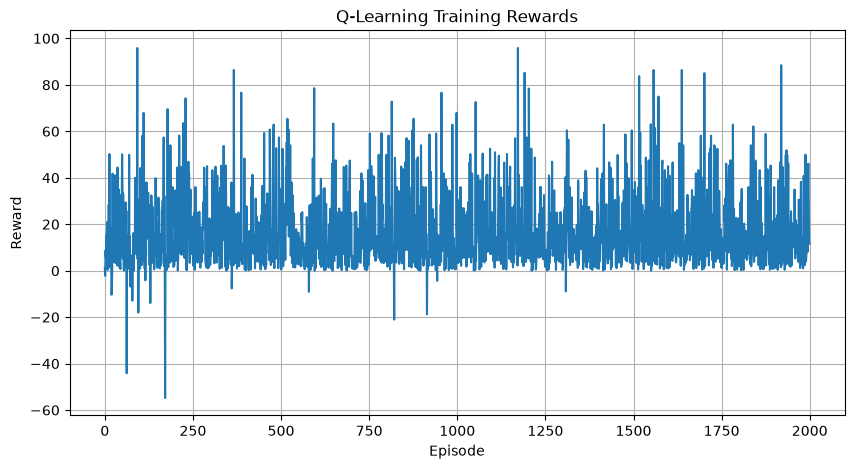

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-Learning Training Rewards")
plt.grid(True)
plt.show()

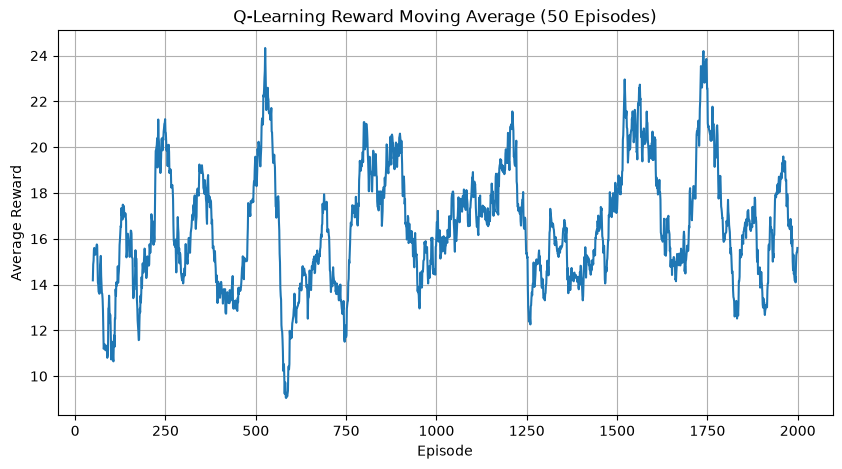

In [90]:
window = 50

moving_average = (
    pd.Series(rewards)
    .rolling(window=window)
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Reward Moving Average (50 Episodes)")
plt.grid(True)
plt.show()

## Results & Business Interpretation

The trained Q-learning agent was evaluated across multiple casino machine operating conditions. The evaluation focused on the agent's learned action preferences, measured rewards, and performance compared with simple fixed-action strategies.

The results show that the agent learned different action preferences depending on the machine state rather than selecting the same action for every situation. This indicates that the state variables influenced the agent's decisions.

## Learned Agent Behavior

The agent could select among three operational actions:

- **Action 0 — Maintain:** Keep the current operating configuration.
- **Action 1 — Increase Bet:** Apply an increase to the betting configuration.
- **Action 2 — Adjust Payout:** Apply an adjustment to the payout configuration.

Because the reward function is state-dependent, the same action does not produce the same outcome for every machine state. Some operational adjustments generated positive rewards under certain conditions while producing negative rewards under others.

This behavior is important from a business perspective because casino machines may operate under different conditions. A decision that benefits one machine may not benefit another. The reinforcement learning approach attempts to use the available state information to choose an action appropriate for each individual situation.

## Fixed-Policy Baseline Comparison

To evaluate whether the learned policy provides value beyond a simple fixed strategy, all policies were tested on the **same 100 machine states** using a fixed random seed for reproducibility.

The measured average rewards were:

- **Always Adjust Payout:** 14.01
- **Always Increase Bet:** 14.15
- **Always Maintain:** 18.87
- **Learned Q-Learning Policy:** 18.53

In this evaluation, **Always Maintain produced the highest average measured reward at 18.87**, while the learned Q-learning policy achieved an average reward of 18.53. The difference was approximately **0.34 reward points**.

The learned policy therefore performed similarly to the strongest fixed-action baseline but did not outperform it in this run. The comparison also showed that **Increase Bet** and **Adjust Payout** can produce negative rewards for some machine states. The learned policy also produced a negative minimum reward, showing that its state-dependent decisions do not guarantee an improvement for every machine.

Overall, the results provide evidence that the agent learned a **state-dependent decision policy**, but they also reveal an important limitation: the learned policy did not consistently outperform the strongest simple baseline. Additional training, reward-function refinement, and hyperparameter tuning could be explored to improve future performance.

## Final Analysis & Conclusion

The reinforcement learning model demonstrated how a Q-learning agent can learn operational decision strategies from a simulated casino revenue environment. The agent used machine-level operating conditions—including average bet, payout rate, days active, service frequency, and machine swapouts—to represent the state of the environment.

During training, the agent explored different actions and updated its Q-values based on the immediate rewards it received. Because this is a one-step decision environment, the Q-learning update uses the measured immediate reward rather than estimating future rewards. As training progressed, epsilon decreased to 0.05, shifting the agent from exploration toward greater use of its learned policy.

Evaluation across 100 machine states showed that the agent learned a state-dependent policy rather than simply selecting the same action for every machine. However, the learned Q-learning policy achieved an average reward of 18.53 compared with 18.87 for the strongest fixed baseline, Always Maintain. Therefore, the learned policy performed similarly to, but did not outperform, the strongest fixed strategy in this evaluation.

The results demonstrate a proof of concept for applying reinforcement learning to casino revenue optimization while also showing the importance of baseline comparisons when evaluating an RL agent. Because this project uses synthetic historical data and a simplified simulated reward structure, the learned policy should be interpreted as an experimental model rather than a recommendation for real-world casino operations.

## Limitations & Future Improvements

This project has several limitations. The dataset is synthetic, and the reinforcement learning environment simplifies real-world casino operations into a limited number of states and actions. The current environment is also a **one-step decision environment**, meaning each episode evaluates a single operational action rather than a sequence of decisions over time.

Because the environment terminates after one action, the agent learns from the immediate measured reward and does not model the long-term consequences of its decisions. This limits the project's ability to represent more complex real-world operational strategies.

Future improvements could include developing a multi-step environment with longer episodes, creating more complex reward functions, increasing the number of available actions, comparing Q-learning with more advanced reinforcement learning algorithms, and validating the approach with larger or more realistic datasets.

These improvements could provide a more sophisticated framework for studying how reinforcement learning can support revenue optimization and operational decision-making.

## RL Experiment: Learning Rate Comparison

To evaluate how the Q-learning configuration affects agent learning, this experiment compares different learning rates while keeping the remaining training parameters consistent. The goal is to determine whether changing the learning rate affects training performance and the agent's ability to learn useful Q-values.

In [91]:
learning_rates = [0.01, 0.1, 0.5]
experiment_results = []

for test_alpha in learning_rates:
    experiment_q_table = np.zeros((5, 5, 5, 3, 2, 3))
    experiment_rewards = []
    experiment_epsilon = 1.0

    for episode in range(1000):
        obs, info = env.reset()

        state_df = pd.DataFrame(
            [obs],
            columns=state_data.columns
        )

        state = discretizer.transform(
            state_df
        )[0].astype(int)

        if np.random.random() < experiment_epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(
                experiment_q_table[tuple(state)]
            )

        next_obs, reward, terminated, truncated, info = env.step(
            action
        )

        current_q = experiment_q_table[tuple(state)][action]

        # One-step environment:
        # learn directly from the immediate measured reward.
        experiment_q_table[tuple(state)][action] = (
            current_q
            + test_alpha
            * (
                reward - current_q
            )
        )

        experiment_rewards.append(reward)

        experiment_epsilon = max(
            epsilon_min,
            experiment_epsilon * epsilon_decay
        )

    experiment_results.append({
        "Learning Rate": test_alpha,
        "Average Reward": np.mean(experiment_rewards),
        "Maximum Q-Value": np.max(experiment_q_table),
        "Learned Q-Values": np.count_nonzero(experiment_q_table)
    })

experiment_df = pd.DataFrame(experiment_results)

experiment_df

,Learning Rate,Average Reward,Maximum Q-Value,Learned Q-Values
0,0.01,18.358469,7.414963,260
1,0.10,16.807807,30.318525,275
2,0.50,17.833382,71.085046,264


## Experiment Results

The learning-rate experiment compared alpha values of 0.01, 0.10, and 0.50 across 1,000 training episodes.

In this experimental run, the learning rate of **0.01 produced the highest average reward (18.36)**. Alpha = 0.50 produced an average reward of **17.83**, while alpha = 0.10 produced an average reward of **16.81**.

The number of non-zero learned Q-values also varied across the experiments. Alpha = 0.01 produced **260 learned Q-values**, alpha = 0.10 produced **275**, and alpha = 0.50 produced **264**.

The maximum Q-value increased substantially as the learning rate increased, from approximately **7.41** at alpha = 0.01 to **30.32** at alpha = 0.10 and **71.09** at alpha = 0.50. However, the larger Q-values did not correspond to a higher average reward.

These results demonstrate that the learning rate affects how quickly the agent updates its value estimates. In this run, the lower learning rate of **0.01 achieved the highest average reward**, although this experiment alone is not sufficient to conclude that 0.01 is always the best learning rate.

Because the environment uses randomized states and epsilon-greedy exploration, results may vary across repeated training runs.